In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import unityandnormal as u_n
import os
from datetime import timedelta
import pymannkendall as mk
from pyextremes import EVA
from pyextremes import plot_threshold_stability
import DataAndCorr as DC

In [2]:
xar = DC.Qtomonth("Data/Discharges/Duero/Q_Duero_0.nc", "0")
df1 = xar.to_dataframe()
# df1 = df1.iloc[1000:]
xal = DC.Qtomonth("Data/Discharges/Q_Rijn_0.nc", "0")
df2 = xal.to_dataframe()
# print(df1)

In [ ]:
def extremesss(dfs, name, thresh, declust):
    f, axs = plt.subplots(1,len(thresh))

    models = []

    for ax, df, n, th, dec in zip(axs, dfs, name, thresh, declust):
        df = df.dropna()
        model = EVA(df['0'])
        model.data.name = n
        # i  = 250
        model.get_extremes(method="POT", threshold=th, r=dec)
        model.fit_model()

        
        model.plot_return_values(alpha=0.95, ax=ax, figsize=(8,5))
        ax.lines[2].set_label(f"Genpareto fit: \nc: {model.distribution.mle_parameters["c"].round(3)} \nshape: {int(model.distribution.mle_parameters["scale"])}")
        ax.lines[0].set_label("CI: \nalpha = 0.95")
        # print(ax.properties)
        ax.legend()
        f.subplots_adjust(wspace=0.5)

        model.plot_extremes(figsize=(13,8))
        # plot_threshold_stability(
        #     df['0'],
        #     return_period=100,
        #     thresholds=np.linspace(th-th/5, th+th/5, 20),
        #     r=dec
        # )
        models.append(model)
    return models

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:        Discharge Duero [m3/s]      Size:                              34,477
Start:                       January 1912      End:                       September 2021
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                203      Extraction method:                    POT
Type:                                high      Threshold:                            360
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

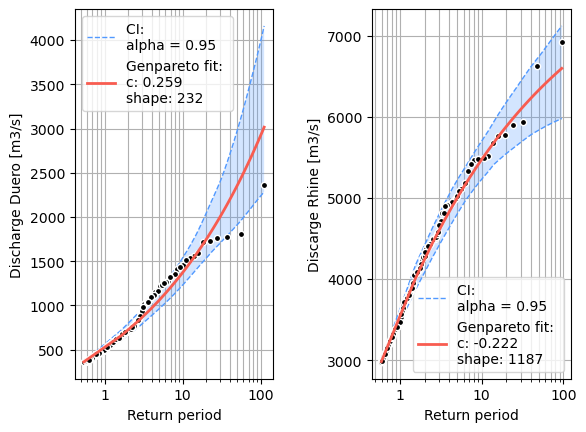

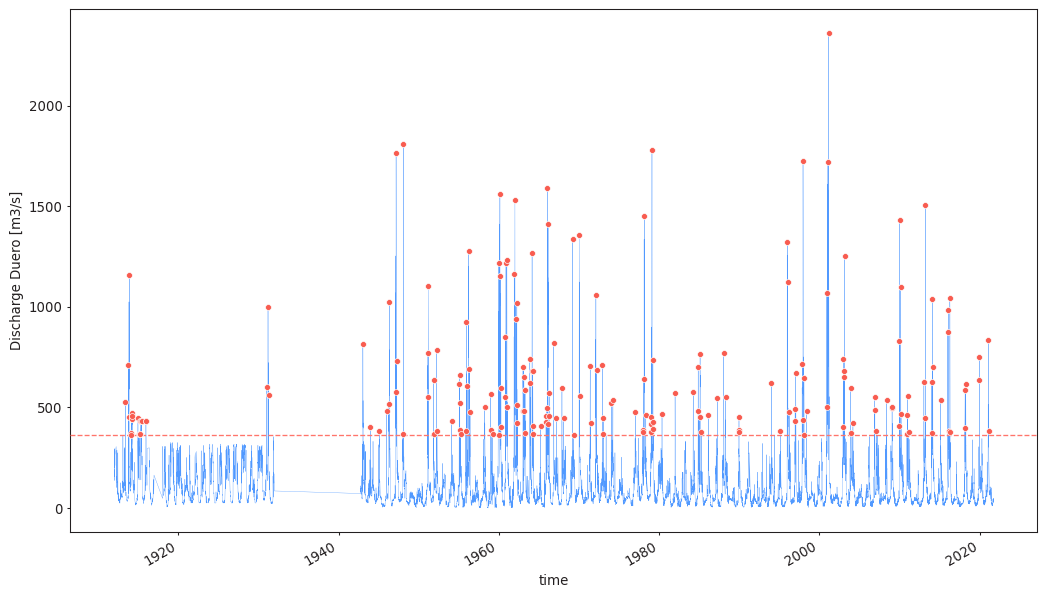

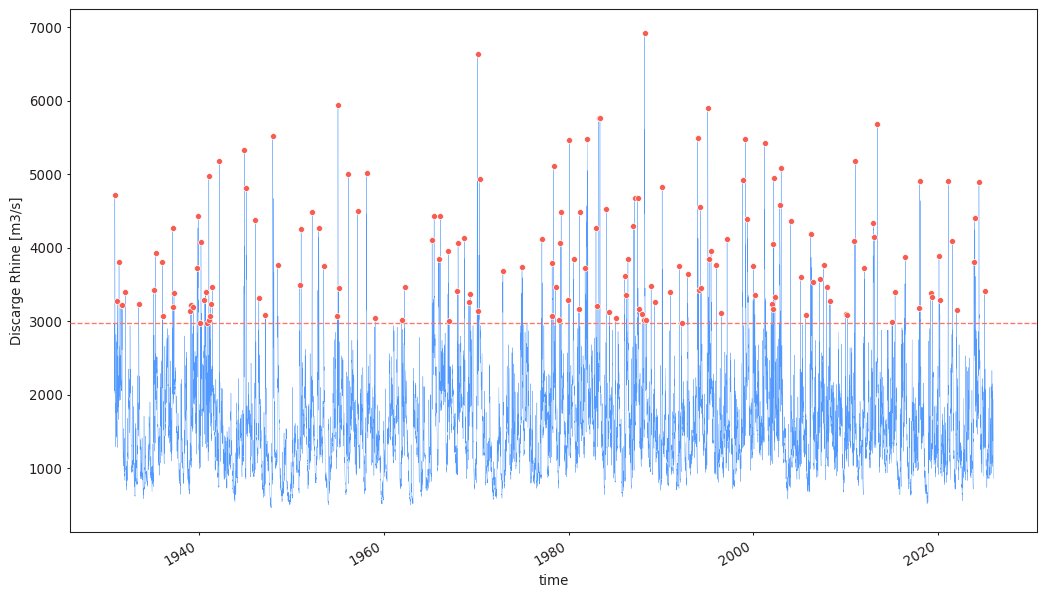

In [10]:
Qs = extremesss([df1, df2], ["Discharge Duero [m3/s]", "Discarge Rhine [m3/s]"], [360, 2970], ["48h", "15d"])
print(Qs[0], Qs[1])

In [5]:
# locs = ["Data/DueroData.pkl", "Data/RijnData.pkl"]

# df1 = pd.read_pickle(locs[0])
df1 = df1.dropna()
# df2 = pd.read_pickle(locs[1])
df2 = df2.dropna()


In [6]:
Q_Carrascal = [Qs[0].extremes, df1['0'].resample("YE").max(), df1['0'].resample("YE").mean()]
# Q = df['0'].resample("YE").mean()
# Q_Carrascal = Q_Carrascal.dropna()

Q_Mainz = [Qs[1].extremes, df2['0'].resample("YE").max(), df2['0'].resample("YE").mean()]
# Q = df['0'].resample("YE").mean()
# Q_Mainz = Q_Mainz.dropna()
# print(Q)
# pd.plotting.autocorrelation_plot(Q)

In [7]:
allres = []
for Q in [*Q_Carrascal, *Q_Mainz]:
    allres.append(mk.original_test(Q))

In [8]:
print(len(allres))

6


[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
203
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.2321915847853009), z=np.float64(1.1947324372609527), Tau=np.float64(0.05643076622933229), s=np.float64(1157.0), var_s=np.float64(936212.3333333334), slope=np.float64(0.18932926829268298), intercept=np.float64(514.997743902439))
110
Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.03133540441852012), z=np.float64(2.152787227379504), Tau=np.float64(0.14698000412286127), s=np.float64(713.0), var_s=np.float64(109385.0), slope=np.float64(2.134831460674157), intercept=np.float64(406.03011235955057))
110
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.08162645314821693), z=np.float64(-1.7413259891265662), Tau=np.float64(-0.11894454751597609), s=np.float64(-577.0), var_s=109417.0, slope=np.float64(-0.2622276501244295), intercept=np.float64(119.12264807850403))
163
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.18575

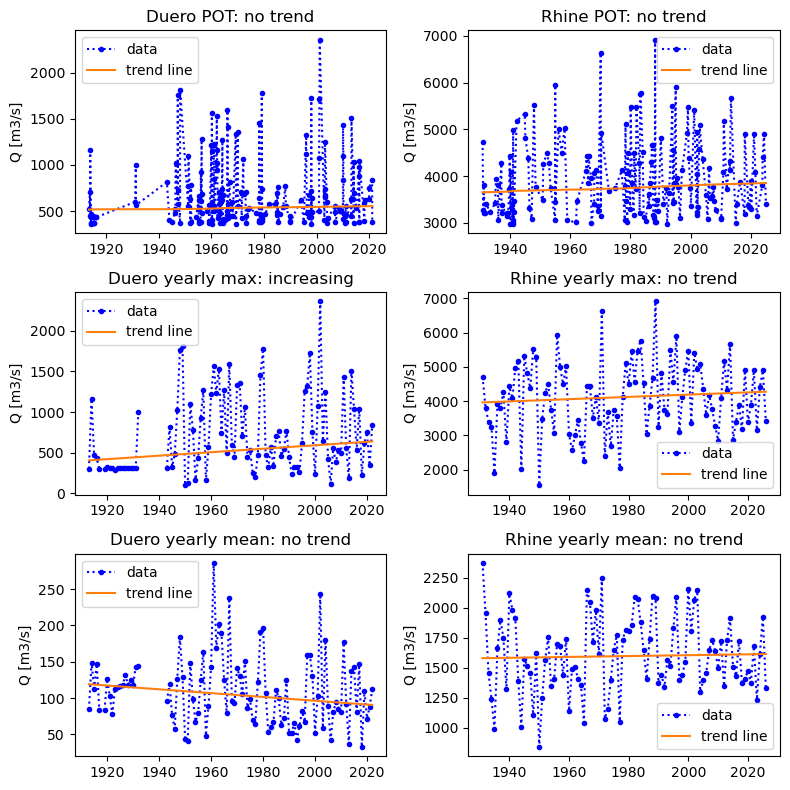

In [9]:
fig, axs = plt.subplots(3,2,figsize=(8, 8))
print(axs)
# print(len(axs))
for Q, res, ax, title in zip([*Q_Carrascal, *Q_Mainz], allres,[*axs[:,0],*axs[:,1]], ["Duero POT","Duero yearly max", "Duero yearly mean","Rhine POT", "Rhine yearly max", "Rhine yearly mean"]):
    data = Q
    print(len(data))
    # ax=ax[0]
    # res = mk.seasonal_test(data)
    trend_line = np.arange(len(data)) * res.slope + res.intercept
    print(res)
    ax.plot(data, 'b.:')
    ax.plot(data.index, trend_line, "tab:orange")
    ax.legend(['data', 'trend line'])
    ax.set_title(f"{title}: {res.trend}")
    ax.set_ylabel("Q [m3/s]")
    # ax.set_figure(fmt = '^k:')
fig.tight_layout()